In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/e_commerce_customer_behavior.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [19]:
from src.data_cleaning import load_and_clean
df = load_and_clean("../data/e_commerce_customer_behavior.csv")
df.shape, df.isnull().sum()

/home/ahmed-elatar/data_analysis_repos/Customer-Churn-Analysis/src/data_cleaning.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


((350, 11),
 Customer_ID                 0
 Gender                      0
 Age                         0
 City                        0
 Membership_Type             0
 Total_Spend                 0
 Items_Purchased             0
 Average_Rating              0
 Discount_Applied            0
 Days_Since_Last_Purchase    0
 Satisfaction_Level          0
 dtype: int64)

In [20]:
from src.feature_engineering import add_features
df = add_features(df)
df[['Age','Age_Group','Total_Spend','Customer_Value','At_Risk']].head()

,Age,Age_Group,Total_Spend,Customer_Value,At_Risk
0,29,26-35,1120.20,High,False
1,34,26-35,780.50,Medium,False
2,43,36-45,510.75,Low,True
3,30,26-35,1480.30,High,False
4,27,26-35,720.40,Medium,True


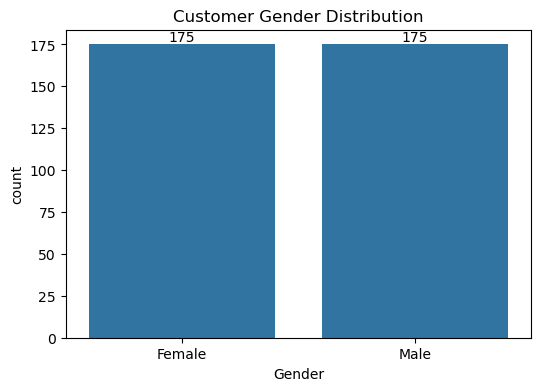

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Capture the plot in a variable called 'ax'
ax = sns.countplot(x='Gender', data=df)

# Add the labels to the bars
ax.bar_label(ax.containers[0])

plt.title('Customer Gender Distribution')

# Remember: Save BEFORE Show!
plt.savefig('../images/gender_distribution.png', bbox_inches='tight')
plt.show()

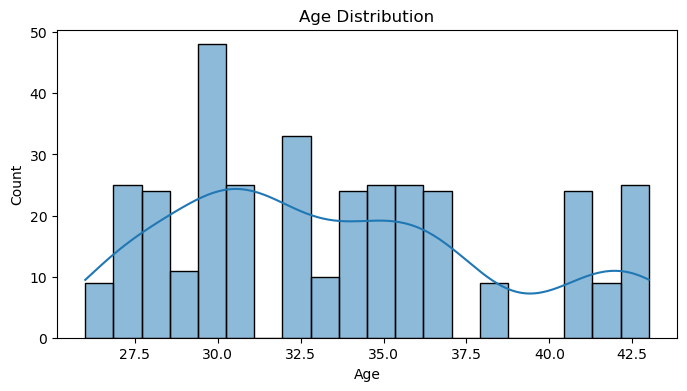

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.savefig('../images/age_distribution.png', bbox_inches='tight')
plt.show()

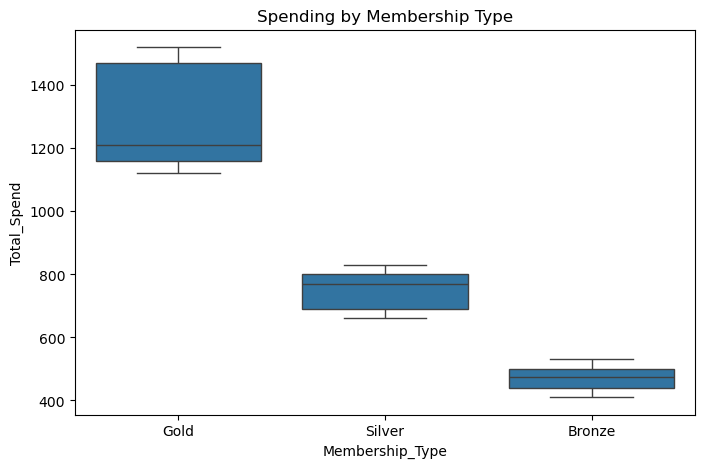

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Membership_Type', y='Total_Spend', data=df)
plt.title('Spending by Membership Type')
plt.savefig('../images/spending_by_membership.png', bbox_inches='tight')
plt.show()

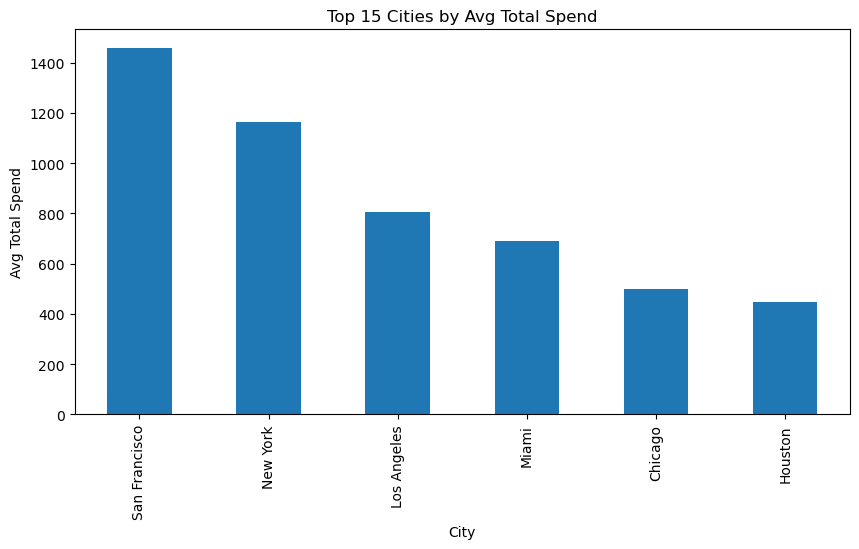

In [25]:
city_spend = df.groupby('City')['Total_Spend'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,5))
city_spend.plot(kind='bar')
plt.title('Top 15 Cities by Avg Total Spend')
plt.ylabel('Avg Total Spend')
plt.savefig('../images/top_cities_spend.png', bbox_inches='tight')
plt.show()


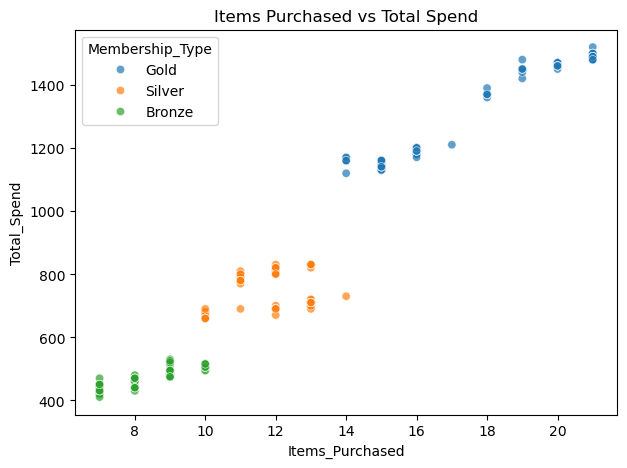

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Items_Purchased', y='Total_Spend', hue='Membership_Type', data=df, alpha=0.7)
plt.title('Items Purchased vs Total Spend')
plt.savefig('../images/items_vs_spend.png', bbox_inches='tight')
plt.show()

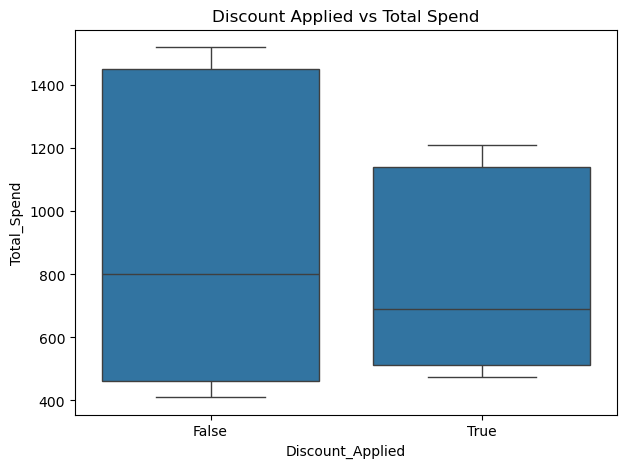

In [27]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Discount_Applied', y='Total_Spend', data=df)
plt.title('Discount Applied vs Total Spend')
plt.savefig('../images/discount_vs_spend.png', bbox_inches='tight')
plt.show()

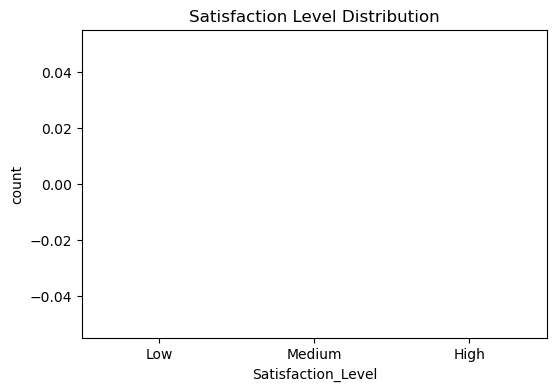

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='Satisfaction_Level', data=df, order=['Low','Medium','High'])
plt.title('Satisfaction Level Distribution')
plt.savefig('../images/satisfaction_distribution.png', bbox_inches='tight')
plt.show()

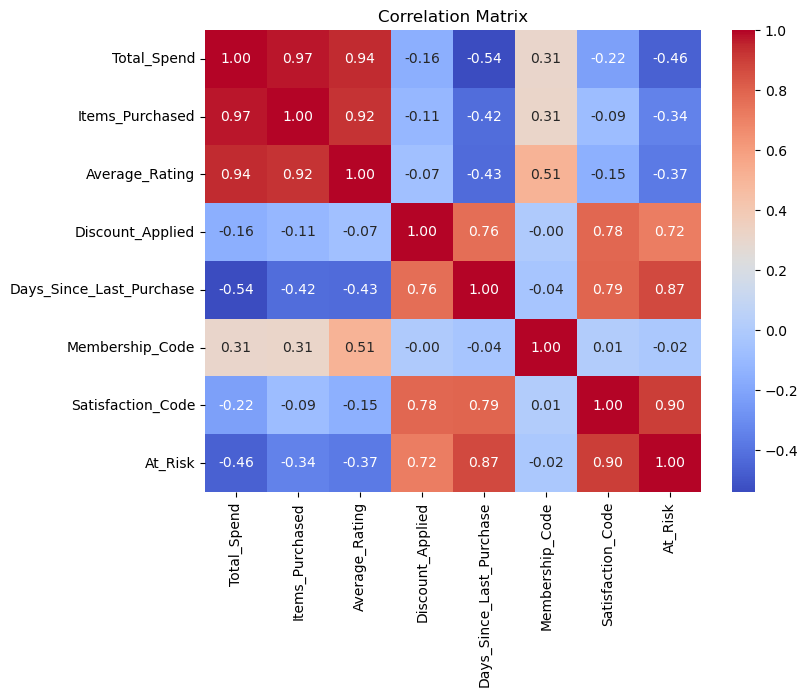

In [29]:
# quick encoding for numeric correlation
df_num = df.copy()
df_num['Discount_Applied'] = df_num['Discount_Applied'].astype(int)
df_num['At_Risk'] = df_num['At_Risk'].astype(int)
df_num['High_Rating'] = df_num['High_Rating'].astype(int)
# convert membership type and satisfaction level to codes for correlation
df_num['Membership_Code'] = df_num['Membership_Type'].astype('category').cat.codes
df_num['Satisfaction_Code'] = df_num['Satisfaction_Level'].astype('category').cat.codes

corr = df_num[['Total_Spend','Items_Purchased','Average_Rating','Discount_Applied','Days_Since_Last_Purchase','Membership_Code','Satisfaction_Code','At_Risk']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('../images/correlation_matrix.png', bbox_inches='tight')
plt.show()

In [31]:
top_customers = df.sort_values('Total_Spend', ascending=False).head(10)[['Customer_ID','City','Membership_Type','Total_Spend','Items_Purchased','Average_Rating']]
top_customers.to_csv('../images/top_10_customers.csv', index=False)
top_customers

,Customer_ID,City,Membership_Type,Total_Spend,Items_Purchased,Average_Rating
9,110,San Francisco,Gold,1520.1,21,4.8
117,218,San Francisco,Gold,1500.1,21,4.9
87,188,San Francisco,Gold,1500.1,21,4.9
159,260,San Francisco,Gold,1500.1,21,4.9
189,290,San Francisco,Gold,1500.1,21,4.9
57,158,San Francisco,Gold,1500.1,21,4.9
230,331,San Francisco,Gold,1500.1,21,4.9
27,128,San Francisco,Gold,1500.1,21,4.9
45,146,San Francisco,Gold,1490.1,21,4.9
105,206,San Francisco,Gold,1490.1,21,4.9


In [32]:
at_risk = df[df['At_Risk']].copy()
len(at_risk), at_risk['Customer_Value'].value_counts()

(124,
 Customer_Value
 Low       61
 Medium    57
 High       6
 Name: count, dtype: int64)

In [33]:
priority = at_risk.sort_values(['Customer_Value','Total_Spend'], ascending=[False, False])
priority[['Customer_ID','City','Membership_Type','Total_Spend','Days_Since_Last_Purchase','Satisfaction_Level']].head(50).to_csv('../images/at_risk_top50.csv', index=False)

In [36]:
from src.modeling import train_high_value_model
model = train_high_value_model(df)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        23

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

AUC: 1.0
